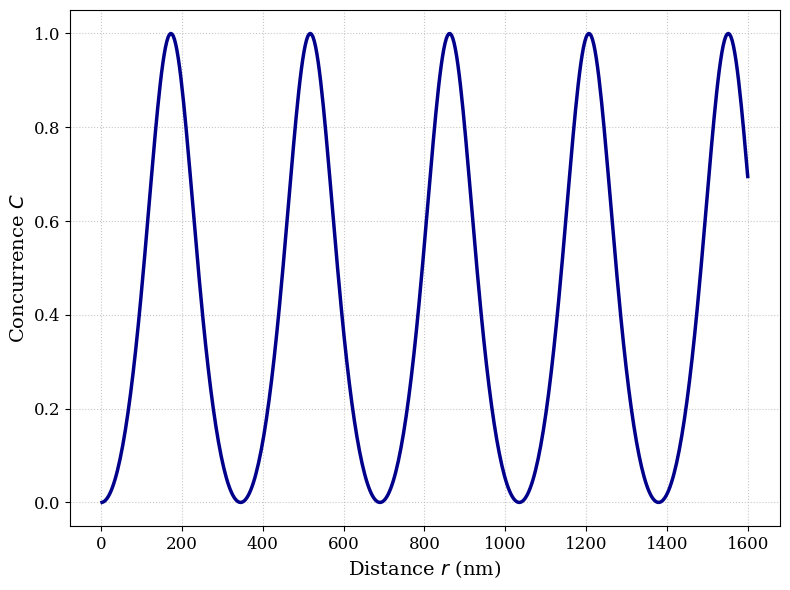

In [3]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sys_params import Constants, ConfigParameters, SystemParameters
from system_ops import SystemOperators, concurrence
from rates import CombinedRates
from br_tensor import BlochRedfieldCalculator
from analysis import CoreAnalysis, EntanglementAnalysis

warnings.filterwarnings('ignore')
mpl.rcParams['text.usetex'] = False

n_points = 500
r_vals_nm = np.linspace(2, 1600, n_points)
C_vals = np.zeros_like(r_vals_nm)

config = ConfigParameters(
    config_name="H", 
    mode="weak", 
    pump="none", 
    integration_method="vectorised",
    data_dir="files/dipole_positions/" 
)
constants = Constants()

theta_k, phi_k = 0.0, 0.0  
theta_kp, phi_kp = np.pi, 0.0

for idx, r in enumerate(r_vals_nm):
    sys_params = SystemParameters(
        constants=constants, 
        config_params=config, 
        E_q1_eV=1.8, 
        E_q2_eV=1.8,
        T_opt=1.0, 
        T_vib=4.0,
        r_nm=r 
    )
    sys_params.calculate_parameters()
    
    sys_params.gamma_p_1 = 0.0
    sys_params.gamma_p_2 = 0.0
    
    rates = CombinedRates(sys_params)
    sys_ops = SystemOperators(sys_params, rates)
    
    psi0 = np.array([1, 0, 0, 0], dtype=complex)
    _, rho0 = sys_ops.initial_state(psi0)
    
    a_ops_opt = [sys_ops.sp1, sys_ops.sm1, sys_ops.sp2, sys_ops.sm2]
    a_ops_vib = [sys_ops.sz1, sys_ops.sz2]
    a_ops_coup = [sys_ops.sp1 @ sys_ops.sm2, sys_ops.sm1 @ sys_ops.sp2]
    
    br_calc = BlochRedfieldCalculator(
        system_params=sys_params, rates=rates, H=sys_ops.H,
        a_ops_opt=a_ops_opt, Gamma_opt=rates.Opt_rate(),
        a_ops_vib=a_ops_vib, Gamma_vib=rates.Vib_rate(),
        a_ops_coup=a_ops_coup, Gamma_coup=rates.Coup_rate(),
        P_vib=rates.P_weight()
    )
    
    tf_decay = 20000.0  
    steps_decay = 500
    
    core = CoreAnalysis(
        system_params=sys_params, BR_calculator=br_calc, rates=rates, 
        final_time=tf_decay, steps=steps_decay, rho_init=rho0, ss_method=None
    )
    
    ent_analysis = EntanglementAnalysis(core, tau_final=0.0, tau_steps=1)
    
    rho_t_tau = ent_analysis.two_photon_density_matrix(theta_k, phi_k, theta_kp, phi_kp)
    
    rho_tau_0 = rho_t_tau[:, 0, :, :]
    rho_int = np.trapz(rho_tau_0, x=core.times, axis=0)
    
    C_vals[idx] = concurrence(rho_int)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(r_vals_nm, C_vals, color='darkblue', linewidth=2.5)

ax.set_xlabel(r'Distance $r$ (nm)', fontsize=14)
ax.set_ylabel(r'Concurrence $C$', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()